In [14]:
import pandas as pd
import requests
from scipy import stats
import numpy as np

# Load data
statistics_url = 'https://www.guess-vs-ai.com/api/statistics'
response = requests.get(statistics_url).json()
data = response.get('result')

# Basic info
total_games = data['totalGames']
total_ai_wins = data['totalAIWins']
total_human_wins = data['totalHumanWins']
total_given_up = data['totalGivenUp']
total_started = data['totalStarted']

print("Total Games:", total_games)
print("Total AI Wins:", total_ai_wins)
print("Total Human Wins:", total_human_wins)
print("Total Given Up:", total_given_up)
print("Total Started:", total_started)

# Create a DataFrame from winsByCategory
df = pd.json_normalize(data['winsByCategory'])

# Let's look at the DataFrame
df

Total Games: 47
Total AI Wins: 33
Total Human Wins: 14
Total Given Up: 26
Total Started: 149


,aiWins,humanWins,givenUp,started,minQuestionCountAI,maxQuestionCountAI,medQuestionCountAI,avgQuestionCountAI,minQuestionCountHuman,maxQuestionCountHuman,medQuestionCountHuman,avgQuestionCountHuman,category.name,category.description,category.type,category.icon.prefix,category.icon.iconName,category.icon.icon,category.image
0,7,1,5,31,4,10,6,6.142857,18,18,18,18.000000,Marvel Universe,Select a character from any movie or series wi...,Theme,fas,shield,"[512, 512, [128737, shield-blank], f132, M256 ...",/images/shield.webp
1,9,3,7,30,5,9,5,6.444444,12,13,13,12.666667,Harry Potter,Pick a character from the Harry Potter univers...,Theme,fas,wand-sparkles,"[512, 512, [], f72b, M464 6.1c9.5-8.5 24-8.1 3...",/images/harrypotter.PNG
2,6,1,4,20,6,15,15,9.833333,22,22,22,22.000000,Star Wars,"Choose a character from the Star Wars saga, in...",Theme,fas,jedi,"[576, 512, [], f669, M246 315.7l-21.2-31.9c-2....",/images/stormtrooper.png
3,9,8,6,48,7,25,10,12.333333,14,56,25,25.750000,Historical Figures,"Pick a famous historical figure from any era, ...",Theme,fas,book,"[448, 512, [128212], f02d, M96 0C43 0 0 43 0 9...",/images/sokrates.PNG
4,2,1,4,20,7,11,7,9.000000,13,13,13,13.000000,Disney Animal,An animal character featured in any Disney ani...,Theme,fas,paw,"[512, 512, [], f1b0, M226.5 92.9c14.3 42.9-.3 ...",/images/Guess vs AI logo.png


# Completions + Give-ups + Abandoned:
“Completions” can be understood as total games that resulted in a win (either AI or human), “Give ups” as totalGivenUp, and “Abandoned” might be inferred from totalStarted - totalGames (since totalGames might represent fully completed games). You can calculate these:

In [15]:
completed_games = total_ai_wins + total_human_wins
give_ups = total_given_up
abandoned = total_started - total_games  # This is an assumption based on naming

print("Completed Games:", completed_games)
print("Give-ups:", give_ups)
print("Abandoned:", abandoned)

Completed Games: 47
Give-ups: 26
Abandoned: 102


# Successfully operated %:
You might define “successfully operated” as (Completed Games + Give-ups) / Total Started or just Completed/Total Started depending on the interpretation.

In [16]:
successfully_operated_pct = (completed_games + give_ups) / total_started * 100
print("Successfully Operated %:", successfully_operated_pct)

Successfully Operated %: 48.99328859060403


# Checking Normality for Distributions

You mentioned checking normality (e.g., for question counts). Let’s extract the arrays of question counts for humans and AI across categories. For instance, you can look at avgQuestionCountHuman and avgQuestionCountAI across categories as an initial measure.

In [17]:
avg_questions_human = df['avgQuestionCountHuman'].dropna()
avg_questions_ai = df['avgQuestionCountAI'].dropna()

# Shapiro-Wilk Test for normality
shapiro_human = stats.shapiro(avg_questions_human)
shapiro_ai = stats.shapiro(avg_questions_ai)

print("Shapiro-Wilk Test (Human):", shapiro_human)
print("Shapiro-Wilk Test (AI):", shapiro_ai)

# Alternatively, Kolmogorov-Smirnov test
ks_human = stats.kstest(avg_questions_human, 'norm', args=(avg_questions_human.mean(), avg_questions_human.std()))
ks_ai = stats.kstest(avg_questions_ai, 'norm', args=(avg_questions_ai.mean(), avg_questions_ai.std()))

print("K-S Test (Human):", ks_human)
print("K-S Test (AI):", ks_ai)

Shapiro-Wilk Test (Human): ShapiroResult(statistic=np.float64(0.9148487487296915), pvalue=np.float64(0.4972691060107609))
Shapiro-Wilk Test (AI): ShapiroResult(statistic=np.float64(0.9289463689308898), pvalue=np.float64(0.5892032230265427))
K-S Test (Human): KstestResult(statistic=np.float64(0.2238048081890962), pvalue=np.float64(0.915750760350444), statistic_location=np.float64(13.0), statistic_sign=np.int8(1))
K-S Test (AI): KstestResult(statistic=np.float64(0.2162992922993574), pvalue=np.float64(0.9322073597114149), statistic_location=np.float64(6.444444444444445), statistic_sign=np.int8(1))


# Comparing AI and Human Performance
## Wins Comparison:
You can compare humanWins vs aiWins across categories. Although these are not strictly paired measurements in the traditional sense (since they represent outcomes across different categories), you can still attempt a statistical test if it makes sense in your research question.

In [18]:
human_wins = df['humanWins']
ai_wins = df['aiWins']

# If normal: Paired t-test
# If not normal: Wilcoxon signed-rank test

# Check normality first
shapiro_human_wins = stats.shapiro(human_wins)
shapiro_ai_wins = stats.shapiro(ai_wins)

if shapiro_human_wins.pvalue > 0.05 and shapiro_ai_wins.pvalue > 0.05:
    # Both distributions normal? We could try a paired t-test (although the data might not truly be paired)
    ttest_res = stats.ttest_rel(human_wins, ai_wins)
    print("Paired t-test (Human wins vs. AI wins):", ttest_res)
else:
    # Non-parametric test
    wilcoxon_res = stats.wilcoxon(human_wins, ai_wins)
    print("Wilcoxon signed-rank test (Human wins vs. AI wins):", wilcoxon_res)

Wilcoxon signed-rank test (Human wins vs. AI wins): WilcoxonResult(statistic=np.float64(0.0), pvalue=np.float64(0.0625))


Note: Conceptually, human wins vs. AI wins by category may not be true “paired” data in the statistical sense, as these represent totals from different games. If they are independent categories and not repeated measures of the same scenario, consider a different approach (e.g., comparing distributions or proportions using a chi-square test or other categorical analysis).


# Comparing Efficiency (Question Counts)

You mentioned comparing the number of questions each (AI vs Human) takes. If we consider per-category averages or medians, you can attempt a paired comparison (assuming each category is a “pair” of AI vs. human conditions):

In [19]:
avg_questions_human = df['avgQuestionCountHuman']
avg_questions_ai = df['avgQuestionCountAI']

# Test normality
shapiro_human_q = stats.shapiro(avg_questions_human)
shapiro_ai_q = stats.shapiro(avg_questions_ai)

if shapiro_human_q.pvalue > 0.05 and shapiro_ai_q.pvalue > 0.05:
    # Use a paired t-test
    t_res_questions = stats.ttest_rel(avg_questions_human, avg_questions_ai)
    print("Paired t-test (Avg Questions Human vs. AI):", t_res_questions)
else:
    # Use Wilcoxon signed-rank test
    w_res_questions = stats.wilcoxon(avg_questions_human, avg_questions_ai)
    print("Wilcoxon test (Avg Questions Human vs. AI):", w_res_questions)

Paired t-test (Avg Questions Human vs. AI): TtestResult(statistic=np.float64(5.132293960818336), pvalue=np.float64(0.006827638712326616), df=np.int64(4))


# Additional/Better Analytics Suggestions
## Exploratory Data Analysis (EDA):
Plot histograms or boxplots of question counts.

In [21]:
%pip install seaborn
%pip install matplotlib

2564.92s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 294 kB 2.0 MB/s eta 0:00:01
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


2571.86s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


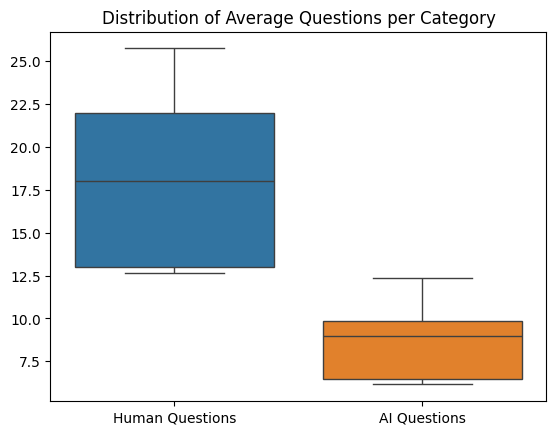

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=[avg_questions_human, avg_questions_ai])
plt.xticks([0,1], ["Human Questions", "AI Questions"])
plt.title("Distribution of Average Questions per Category")
plt.show()

## Effect Size:
If you find a significant difference in means/medians, consider reporting effect sizes (e.g., Cohen’s d) to understand practical significance.

In [23]:
# Cohen's d for difference in avg questions
# d = (mean1 - mean2) / pooled_std
mean_diff = avg_questions_human.mean() - avg_questions_ai.mean()
pooled_std = np.sqrt((avg_questions_human.std()**2 + avg_questions_ai.std()**2)/2)
cohen_d = mean_diff / pooled_std
print("Cohen's d:", cohen_d)

Cohen's d: 2.16359150761549


## Confidence Intervals:
Compute confidence intervals for the means of question counts.

In [24]:
# 95% CI for human questions
human_mean = avg_questions_human.mean()
human_se = avg_questions_human.std()/np.sqrt(len(avg_questions_human))
ci_human = stats.t.interval(0.95, len(avg_questions_human)-1, loc=human_mean, scale=human_se)

# 95% CI for AI questions
ai_mean = avg_questions_ai.mean()
ai_se = avg_questions_ai.std()/np.sqrt(len(avg_questions_ai))
ci_ai = stats.t.interval(0.95, len(avg_questions_ai)-1, loc=ai_mean, scale=ai_se)

print("95% CI for Human average questions:", ci_human)
print("95% CI for AI average questions:", ci_ai)

95% CI for Human average questions: (np.float64(11.229152983987142), np.float64(25.33751368267952))
95% CI for AI average questions: (np.float64(5.573664071610392), np.float64(11.927923229976912))


## Proportions Testing (Chi-Square):
If you want to test if AI wins significantly more often than humans overall (not by category, but total proportions), you can do a chi-square test comparing observed wins to expected: